In [1]:
using Random
using Flux

In [2]:

function holdOut(N::Int, P::Real)
    @assert 0 <= P <= 1 "P debe estar entre 0 y 1"
    indices = randperm(N)  # Generate a random permutation of indexes
    split_point = floor(Int, N * (1 - P))  # Determines cut-off point
    return (indices[1:split_point], indices[split_point+1:end])  # Returns the tuple with the subdatasets
end

holdOut (generic function with 1 method)

In [6]:
sets = holdOut(150, 0.3)
typeof(sets)


Tuple{Vector{Int64}, Vector{Int64}}

In [3]:

function holdOut(N::Int, Pval::Real, Ptest::Real)
    @assert 0 <= Pval + Ptest <= 1 "La suma de Pval y Ptest debe estar entre 0 y 1"
    (train_test, test) = holdOut(N, Ptest)  # Separates the test dataset
    Pval_adjusted = Pval / (1 - Ptest)  # Adjusts Pval for the remaining datasets 
    train, val = holdOut(length(train_test), Pval_adjusted)  # Separates validate dataset from training dataset
    return (train_test[train], train_test[val], test)  # Returns the three datasets
end

holdOut (generic function with 2 methods)

In [12]:
(a, b, c) = holdOut(150, 0.15, 0.15)
x = length(a) + length(b) + length(c)
typeof((a, b, c))


Tuple{Vector{Int64}, Vector{Int64}, Vector{Int64}}

In [35]:
function trainClassANN(topology::AbstractArray{<:Int,1},
    trainingDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}};
    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0,size(trainingDataset[2],2))),
    testDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0,size(trainingDataset[2],2))),
    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
    maxEpochsVal::Int=20)

    println("hola")

    trainingInputs = Float32.(trainingDataset[1]') # Convertir inputs a float32
    validationInputs = Float32.(validationDataset[1]') # Convertir inputs a float32
    testInputs = Float32.(testDataset[1]') # Convertir inputs a float32

    trainingTargets = trainingDataset[2]' # Extraer labels
    validationTargets = validationDataset[2]' # Extraer labels
    testTargets = testDataset[2]' # Extraer labels
    
    numTrainingInputs = size(trainingInputs, 1)
    numTrainingOutputs = size(trainingTargets, 1)
    
    ann = buildClassANN(numTrainingInputs, topology, numTrainingOutputs; transferFunctions) # build ANN
    loss(model, x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y) # loss function
    
    opt_state = Flux.setup(Adam(learningRate), ann) 

    trainingLosses = Float32[] # losses array
    validationLosses = Float32[] # validation losses
    testLosses = Float32[] # test losses array

    push!(trainingLosses, loss(ann, trainingInputs, trainingTargets)) # append epoch 0 loss 

    if !isempty(validationInputs)
        push!(validationLosses, loss(ann, validationInputs, validationTargets))
        bestValidationLoss = validationLosses[1]
        bestAnn = deepcopy(ann)
        epochsWithoutImprovement = 0
    end
    if !isempty(testInputs)
        push!(testLosses, loss(ann, testInputs, testTargets))
    end

    
    epochs = 0
    
    for epoch in 1:maxEpochs
      
        Flux.train!(loss, ann, [(trainingInputs, trainingTargets)], opt_state)
        epochs = epochs + 1
        currentTrainingLoss = loss(ann, trainingInputs, trainingTargets)
        push!(trainingLosses, currentTrainingLoss)
        
        if currentTrainingLoss <= minLoss
            break
        end

        # Case: conjunto de test
        if !isempty(testInputs)
            currentTestLoss = loss(ann, testInputs, testTargets)
            push!(testLosses, currentTestLoss)
        end

    
        # VALIDACIÓN (si hay conjunto de validación)
        if !isempty(validationInputs)
            currentValidationLoss = loss(ann, validationInputs, validationTargets)
            push!(validationLosses, currentValidationLoss)
            
            # PARADA TEMPRANA: Si el loss en validación mejora, actualizar mejor modelo
            if currentValidationLoss < bestValidationLoss
       
                bestValidationLoss = currentValidationLoss
                bestAnn = deepcopy(ann)
                epochsWithoutImprovement = 0  # Reiniciar el contador de epochs sin mejora
            else
                epochsWithoutImprovement += 1
            end

            if epochsWithoutImprovement >= maxEpochsVal
                println("Parada temprana en epoch $epoch ")
                break
            end
        end
    end

    println("Epochs completados: $epochs")
    println("Tamaño trainingLosses: $(length(trainingLosses))")
    println("Tamaño validationLosses: $(length(validationLosses))")
    println("Tamaño testLosses: $(length(testLosses))")
    
    if !isempty(validationInputs)
        return (bestAnn, trainingLosses, validationLosses, testLosses)
    else
        return (ann, trainingLosses, validationLosses, testLosses)
    end
end;
   

trainClassANN (generic function with 2 methods)

In [36]:
function trainClassANN(topology::AbstractArray{<:Int,1},
    trainingDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}};
    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0)),
    testDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0)),
    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
    maxEpochsVal::Int=20) 

    newTrainingDataset = (trainingDataset[1], reshape(trainingDataset[2], :, 1))
    newValidationDataset = (validationDataset[1], reshape(validationDataset[2], :, 1))
    newTestDataset = (testDataset[1], reshape(testDataset[2], :, 1))

    return trainClassANN(topology, newTrainingDataset; validationDataset=newValidationDataset, testDataset=newTestDataset, 
                         transferFunctions=transferFunctions, maxEpochs=maxEpochs, minLoss=minLoss, 
                         learningRate=learningRate, maxEpochsVal=maxEpochsVal)
end

trainClassANN (generic function with 2 methods)

# Testing pipeline

In [7]:
# Cargamos el dataset
using DelimitedFiles: readdlm
include("/Users/rafa/Documents/Uni/Cuatri4/machine_learning/FAA_practices/src/boletin_1/45159263M_49918198X_48118738R_54153358L.jl")
ruta_rafa = "/Users/rafa/Documents/Uni/Cuatri4/machine_learning/FAA_practices/iris.data"

dataset = readdlm(ruta_rafa,',')

# Preparamos las entradas
inputs = Float32.(dataset[:,1:4])
targets = oneHotEncoding(dataset[:,5])

150×3 Matrix{Bool}:
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 ⋮     
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1

In [8]:
inputs = normalizeZeroMean!(inputs)

150×4 Matrix{Float32}:
 -0.897675    1.02861   -1.33679   -1.30859
 -1.1392     -0.12454   -1.33679   -1.30859
 -1.38073     0.336721  -1.39347   -1.30859
 -1.50149     0.10609   -1.28012   -1.30859
 -1.01844     1.25924   -1.33679   -1.30859
 -0.535385    1.95113   -1.16677   -1.04652
 -1.50149     0.797981  -1.33679   -1.17756
 -1.01844     0.797981  -1.28012   -1.30859
 -1.74302    -0.35517   -1.33679   -1.30859
 -1.1392      0.10609   -1.28012   -1.43963
  ⋮                                
  1.27606     0.10609    0.760212   1.44312
 -0.0523316  -0.816431   0.760212   0.918985
  1.1553      0.336721   1.21362    1.44312
  1.03454     0.567351   1.10027    1.70519
  1.03454    -0.12454    0.816887   1.44312
  0.551485   -1.27769    0.703536   0.918985
  0.793011   -0.12454    0.816887   1.05002
  0.430721    0.797981   0.930239   1.44312
  0.0684316  -0.12454    0.760212   0.787951

In [ ]:
train, val, test = holdOut(150, 0.15, 0.15)

([123, 46, 110, 28, 21, 145, 53, 17, 3, 40  …  118, 119, 132, 51, 75, 64, 121, 100, 37, 48], [139, 86, 148, 135, 15, 120, 91, 117, 101, 114  …  5, 106, 124, 45, 63, 142, 85, 150, 116, 130])

In [44]:
trainInputs = inputs[train, :]
valInputs = inputs[val, :]
testInputs = inputs[test, :]

trainLabels = targets[train, :]
valLabels = targets[val, :]
testLabels = targets[test, :]

size(train, 1)

105

In [45]:
size(val, 1)

23

In [48]:
patience = 10

insights = trainClassANN(
    [8, 6], 
    (trainInputs, trainLabels),
    validationDataset=(valInputs, valLabels),
    testDataset=(testInputs, testLabels),
    transferFunctions=[σ, σ], 
    maxEpochs=100, 
    minLoss=0.0, 
    learningRate=0.1, 
    maxEpochsVal=patience
)

hola
Parada temprana en epoch 62 
Epochs completados: 62
Tamaño trainingLosses: 63
Tamaño validationLosses: 63
Tamaño testLosses: 63


(Chain(Dense(4 => 8, σ), Dense(8 => 6, σ), Dense(6 => 3), softmax), Float32[1.3034822, 1.0978906, 1.0711945, 1.073592, 1.0641918, 1.039057, 1.0031422, 0.96217024, 0.92047065, 0.88040733  …  0.055999447, 0.057027042, 0.056071207, 0.05475546, 0.055130232, 0.055909652, 0.055140603, 0.053734515, 0.053360987, 0.05322592], Float32[1.3236663, 1.1152164, 1.0830799, 1.0791895, 1.0651258, 1.0373867, 1.0004286, 0.95944744, 0.9184509, 0.87966853  …  0.06268319, 0.06641389, 0.06509899, 0.064087965, 0.06898168, 0.07382966, 0.07144542, 0.06575192, 0.06368725, 0.063015245], Float32[1.4308043, 1.1602445, 1.0900041, 1.0669783, 1.0465711, 1.0206786, 0.9904786, 0.9589474, 0.9285782, 0.9004921  …  0.13370696, 0.14811385, 0.13589182, 0.1072903, 0.08064996, 0.066788204, 0.06627635, 0.07566925, 0.087794125, 0.09165664])

In [13]:
size(insights[3])

(101,)

In [14]:
println(insights[3])



Float32[1.3228948, 0.9443179, 0.87023646, 0.8134744, 0.72017527, 0.61894923, 0.5398345, 0.48097178, 0.43214923, 0.39784738, 0.38163736, 0.3738969, 0.36146683, 0.34431532, 0.32992694, 0.32181942, 0.316024, 0.3090362, 0.3024005, 0.2975263, 0.29103577, 0.27894014, 0.2624962, 0.24540566, 0.22795217, 0.20746669, 0.18389574, 0.16071253, 0.14021952, 0.1207189, 0.10089019, 0.083135225, 0.06978311, 0.060358573, 0.054046847, 0.05059944, 0.048483014, 0.04536078, 0.041481603, 0.038381837, 0.036193173, 0.034602877, 0.033231653, 0.031415127, 0.029144207, 0.026982658, 0.02519375, 0.023817249, 0.022788743, 0.021715762, 0.020265136, 0.018739391, 0.017503167, 0.016641371, 0.016117696, 0.015773283, 0.015285899, 0.014510022, 0.013699174, 0.013122159, 0.012846877, 0.012779737, 0.012661441, 0.012284839, 0.011764815, 0.011343989, 0.011142581, 0.011138777, 0.011189785, 0.011109005, 0.010847535, 0.010542208, 0.010359244, 0.0103689665, 0.010515973, 0.010632044, 0.010553474, 0.01028756, 0.009992688, 0.009808044,

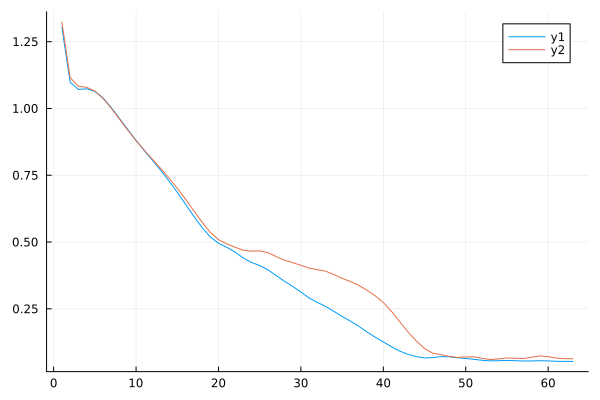

In [49]:
using Plots

p = plot(1:size(insights[2], 1), insights[2])
plot!(p, 1:size(insights[3], 1), insights[3])

In [50]:
try_ann = insights[1]
loss(model, x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y) # loss function
currentValidationLoss = loss(try_ann, valInputs', valLabels')

0.060220424f0

In [51]:
currentValidationLoss == insights[3][size(insights[3], 1) - patience]

true

In [52]:
output_data = try_ann(testInputs')


3×45 Matrix{Float32}:
 0.00165047  0.025909   0.000121713  …  0.000586305  4.64112f-5  0.0026238
 0.248153    0.945629   0.0111196       0.0678644    0.00343745  0.763256
 0.750197    0.0284625  0.988759        0.931549     0.996516    0.23412

In [53]:
accuracy(output_data', testLabels)

0.9333333333333333